<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/binary_deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import torch
import warnings

warnings.filterwarnings("ignore")
torch.__version__

'2.10.0+cpu'

In [109]:
from sklearn.datasets import make_circles

x, y = make_circles(n_samples=1000, random_state=42, noise=0.03)

In [110]:
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [111]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

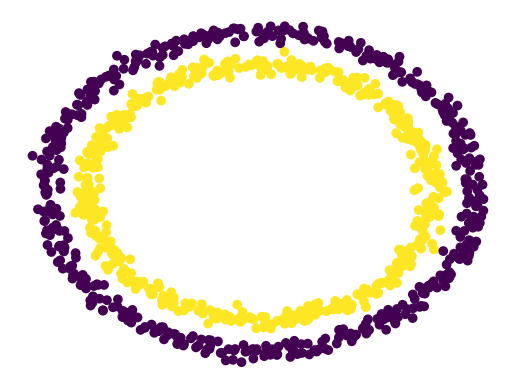

In [112]:
import matplotlib.pyplot as plt

plt.scatter(x[:,0], x[:, 1], c=y)
plt.axis("off")
plt.show()

In [113]:
X_tensor = torch.from_numpy(x)
Y_tensor = torch.from_numpy(y)

In [114]:
X_tensor

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        ...,
        [-0.1369, -0.8100],
        [ 0.6704, -0.7675],
        [ 0.2811,  0.9638]], dtype=torch.float64)

In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2)

In [116]:
X_train

tensor([[-0.4875, -0.8637],
        [ 0.2976,  0.9385],
        [-0.5981, -0.5527],
        ...,
        [ 0.4975, -0.7994],
        [-0.3148, -0.9041],
        [-0.7739,  0.6886]], dtype=torch.float64)

In [117]:
y_train[:5]

tensor([0, 0, 1, 1, 0])

In [118]:
len(X_train), len(X_test)

(800, 200)

In [119]:
from torch import nn

class BinaryClassifier(nn.Module):
  def __init__(self, input_s, output_s, hidden_u):
    super().__init__()
    self.linear = nn.Linear(in_features=input_s, out_features=hidden_u)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(in_features=hidden_u, out_features=output_s)
  def forward(self, x):
    x = self.linear(x)
    x = self.relu(x)
    x = self.linear2(x)
    return x

In [120]:
input_dim = 2
hidden_unit = 10
output_dim = 1

In [121]:
model = BinaryClassifier(input_dim, output_dim, hidden_unit)
model

BinaryClassifier(
  (linear): Linear(in_features=2, out_features=10, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=10, out_features=1, bias=True)
)

In [122]:
test = X_train[0]
test

tensor([-0.4875, -0.8637], dtype=torch.float64)

In [123]:
with torch.inference_mode():
  logit = model(test.float())

logit

tensor([0.1570])

In [124]:
pred = torch.round(torch.sigmoid(logit))
pred

tensor([1.])

In [133]:
from torch.optim import SGD
from torch.nn import  BCEWithLogitsLoss

optimizer = SGD(params=model.parameters(), lr=0.1)
criterion = BCEWithLogitsLoss()

In [134]:
from tqdm import tqdm

In [135]:
def accuracy_fn(ytrue, ypred):
  a = torch.eq(ytrue, ypred).sum().item()
  t = (a/len(ytrue)) * 100
  return t

accuracy_fn(torch.Tensor([1,2,3]), torch.Tensor([1,2,3]))

100.0

In [136]:
TrainAccuracy = []
TrainLoss = []
TestAccuracy = []
TestLoss = []
Epochs = []

In [137]:
from sklearn.metrics import accuracy_score

In [138]:
for epoch in tqdm(range(1000)):
  model.train()
  logits = model(X_train.float())
  pred = torch.round(torch.sigmoid(logits))
  loss = criterion(logits, y_train.unsqueeze(1).float())
  acc = accuracy_score(y_train, pred.detach().numpy())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    te_logits = model(X_test.float())
    te_pred = torch.round(torch.sigmoid(te_logits))
    te_loss = criterion(te_logits, y_test.unsqueeze(1).float())
    te_acc = accuracy_score(y_test, te_pred)

  if epoch % 100 == 0:
    print(f"\n__Epoch__: {epoch}\n")
    print(f"Training Accuracy: {acc:.2f} || Training Loss: {loss:.5f} \n")
    print(f"Testing Accuracy: {te_acc:.2f} || Testing Loss: {te_loss:.5f} ")
    Epochs.append(epoch)
    TrainAccuracy.append(acc)
    TestAccuracy.append(te_acc)
    TrainLoss.append(loss.item())
    TestLoss.append(te_loss.item())

  9%|▉         | 90/1000 [00:00<00:02, 444.07it/s]


__Epoch__: 0

Training Accuracy: 0.56 || Training Loss: 0.68779 

Testing Accuracy: 0.60 || Testing Loss: 0.68553 


 18%|█▊        | 180/1000 [00:00<00:01, 436.28it/s]


__Epoch__: 100

Training Accuracy: 0.60 || Training Loss: 0.68231 

Testing Accuracy: 0.67 || Testing Loss: 0.67979 


 27%|██▋       | 270/1000 [00:00<00:01, 439.98it/s]

...

 87%|████████▋ | 869/1000 [00:02<00:00, 347.62it/s]


__Epoch__: 800

Training Accuracy: 0.90 || Training Loss: 0.60073 

Testing Accuracy: 0.90 || Testing Loss: 0.60139 


 94%|█████████▍| 940/1000 [00:02<00:00, 340.00it/s]


__Epoch__: 900

Training Accuracy: 0.92 || Training Loss: 0.57948 

Testing Accuracy: 0.92 || Testing Loss: 0.58181 


100%|██████████| 1000/1000 [00:02<00:00, 377.55it/s]


In [139]:
Epochs

[0, 100, 200, 300, 400, 500, 600, 700, 800, 900]

In [141]:
print(TestAccuracy)
print(TrainAccuracy)

[0.6, 0.665, 0.73, 0.8, 0.85, 0.845, 0.86, 0.88, 0.9, 0.92]
[0.56, 0.59875, 0.66875, 0.78, 0.82625, 0.85375, 0.85875, 0.8825, 0.89875, 0.92375]


In [142]:
print(TrainLoss)
print(TestLoss)

[0.6877879500389099, 0.6823122501373291, 0.6755989193916321, 0.6677286624908447, 0.6584528088569641, 0.6475865840911865, 0.6346529126167297, 0.6192131042480469, 0.6007304191589355, 0.5794845223426819]
[0.6855250000953674, 0.6797927021980286, 0.6728032827377319, 0.6651162505149841, 0.6561282277107239, 0.645525336265564, 0.6328769326210022, 0.6182026863098145, 0.6013922691345215, 0.5818052291870117]


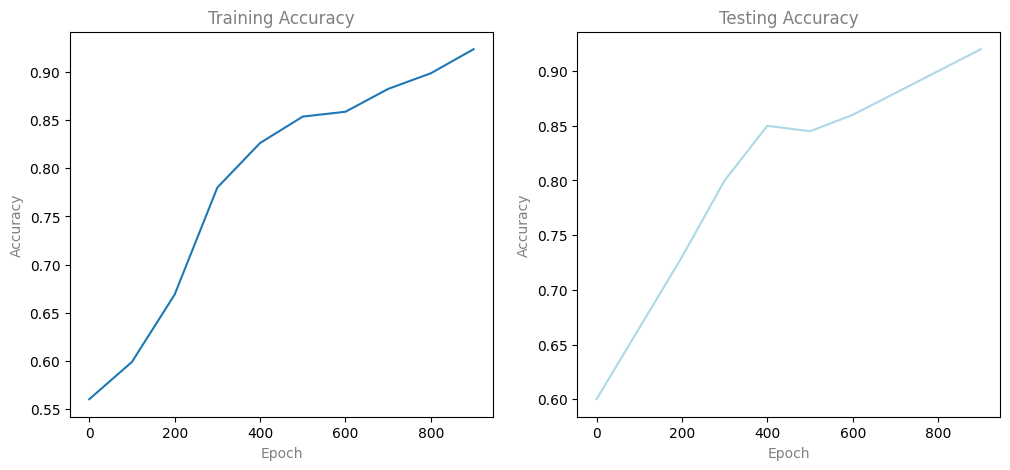

In [161]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(Epochs,TrainAccuracy)
ax[0].set_title("Training Accuracy", c="grey")
ax[0].set_xlabel("Epoch", c="grey")
ax[0].set_ylabel("Accuracy", c="grey")
ax[1].plot(Epochs,TestAccuracy, c="lightblue")
ax[1].set_title("Testing Accuracy", c="grey")
ax[1].set_xlabel("Epoch", c="grey")
ax[1].set_ylabel("Accuracy", c="grey")
plt.show()

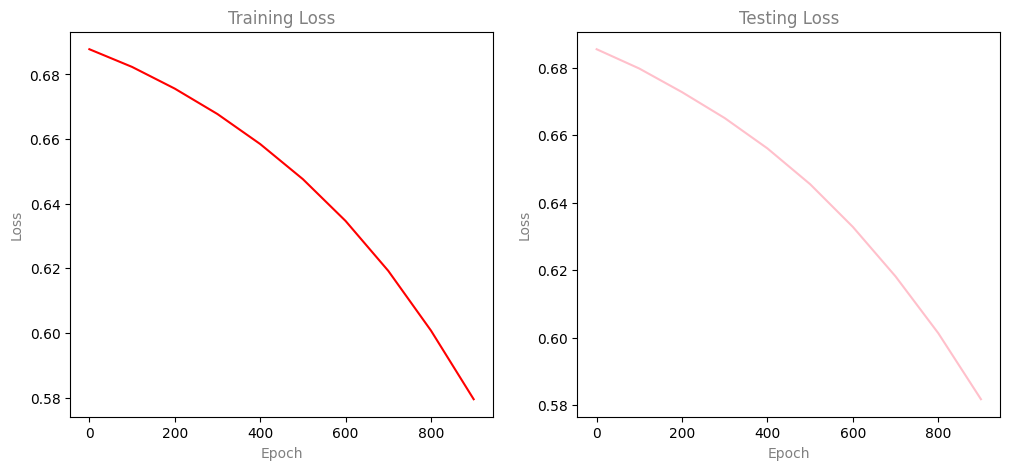

In [157]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(Epochs,TrainLoss, c="red")
ax[0].set_title("Training Loss", c="grey")
ax[0].set_xlabel("Epoch", c="grey")
ax[0].set_ylabel("Loss", c="grey")
ax[1].plot(Epochs,TestLoss, c="pink")
ax[1].set_title("Testing Loss", c="grey")
ax[1].set_xlabel("Epoch", c="grey")
ax[1].set_ylabel("Loss", c="grey")
plt.show()